# Tendências entre os 100 livros em destaque

**Pergunta de negócio:** como os 100 livros em tendência se distribuem por preço, avaliação, ano, autor e gênero, e quais padrões ajudam a acompanhar o catálogo?

**Público:** analista de dados sênior. Os preços estão em dólares e `Rank` representa a posição atual no ranking de tendência.

## Os dados foram lidos corretamente?

Antes de analisar os livros, verificamos formato, tipos e uma amostra para confirmar que preços, notas e rótulos foram interpretados corretamente.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.options.display.float_format = "{:,.2f}".format

livros = pd.read_csv("../../data/Top-100 Trending Books.csv")
livros.shape

(100, 8)

In [2]:
verificacao = pd.DataFrame({
    "tipo": livros.dtypes.astype(str),
    "valores_ausentes": livros.isna().sum(),
})
verificacao

,tipo,valores_ausentes
Rank,int64,0
book title,str,0
book price,float64,0
rating,float64,3
author,str,0
year of publication,int64,0
genre,str,0
url,str,0


In [3]:
livros.head(5)

,Rank,book title,book price,rating,author,year of publication,genre,url
0,1,"Iron Flame (The Empyrean, 2)",18.42,4.10,Rebecca Yarros,2023,Fantasy Romance,amazon.com/Iron-Flame-Empyrean-Rebecca-Yarros/...
1,2,The Woman in Me,20.93,4.50,Britney Spears,2023,Memoir,amazon.com/Woman-Me-Britney-Spears/dp/16680090...
2,3,My Name Is Barbra,31.50,4.50,Barbra Streisand,2023,Autobiography,amazon.com/My-Name-Barbra-Streisand/dp/0525429...
3,4,"Friends, Lovers, and the Big Terrible Thing: A...",23.99,4.40,Matthew Perry,2023,Memoir,amazon.com/Friends-Lovers-Big-Terrible-Thing/d...
4,5,How to Catch a Turkey,5.65,4.80,Adam Wallace,2018,"Childrens, Fiction",amazon.com/How-Catch-Turkey-Adam-Wallace/dp/14...


## A base é adequada para comparar os livros?

Verificamos unicidade do ranking, registros repetidos e campos que limitam comparações.

In [4]:
resumo_qualidade = pd.DataFrame({
    'indicador': ['Linhas', 'Ranks únicos', 'Linhas duplicadas', 'Avaliações ausentes', 'Gêneros distintos'],
    'valor': [len(livros), livros['Rank'].nunique(), livros.duplicated().sum(), livros['rating'].isna().sum(), livros['genre'].nunique()],
})
resumo_qualidade

,indicador,valor
0,Linhas,100
1,Ranks únicos,100
2,Linhas duplicadas,0
3,Avaliações ausentes,3
4,Gêneros distintos,79


**Resultado:** o ranking cobre 100 posições únicas e não há linhas duplicadas. Três livros não têm avaliação; por isso, comparações de nota usarão somente os 97 registros disponíveis. Os 79 rótulos de gênero são muito detalhados e, como alguns combinam várias tags, serão tratados como descrições editoriais, não como categorias padronizadas.

In [5]:
COR_PRIMARIA = '#0072B2'
COR_SECUNDARIA = '#94A3B8'
COR_DESTAQUE = '#E69F00'
COR_EIXO = '#B0B7C3'
COR_TEXTO = '#334155'
plt.rcParams.update({'figure.figsize': (10, 6), 'figure.dpi': 110, 'axes.grid': False, 'axes.spines.top': False, 'axes.spines.right': False, 'axes.edgecolor': COR_EIXO, 'xtick.color': COR_EIXO, 'ytick.color': COR_EIXO})

## Quais autores aparecem mais vezes entre os livros em tendência?

A contagem mostra presença no ranking, não vendas ou participação de mercado.

In [6]:
resumo_autores = (
    livros.groupby('author')
    .agg(livros=('book title', 'size'), melhor_rank=('Rank', 'min'),
         preco_medio=('book price', 'mean'), nota_media=('rating', 'mean'))
    .query('livros >= 2')
    .sort_values(['livros', 'melhor_rank'], ascending=[False, True])
)
resumo_autores.head(10)

,livros,melhor_rank,preco_medio,nota_media
author,,,,
Sarah J. Maas,5,23,20.10,4.75
Adam Wallace,3,5,5.75,4.80
Rebecca Yarros,2,1,17.70,4.45
David Grann,2,9,12.58,4.45
Suzanne Collins,2,11,13.39,4.60
Bill Martin Jr.,2,30,8.56,4.90
Alice Walstead,2,34,13.44,4.70
Sandra Boynton,2,38,8.19,4.80
Lucy Score,2,53,9.21,4.55


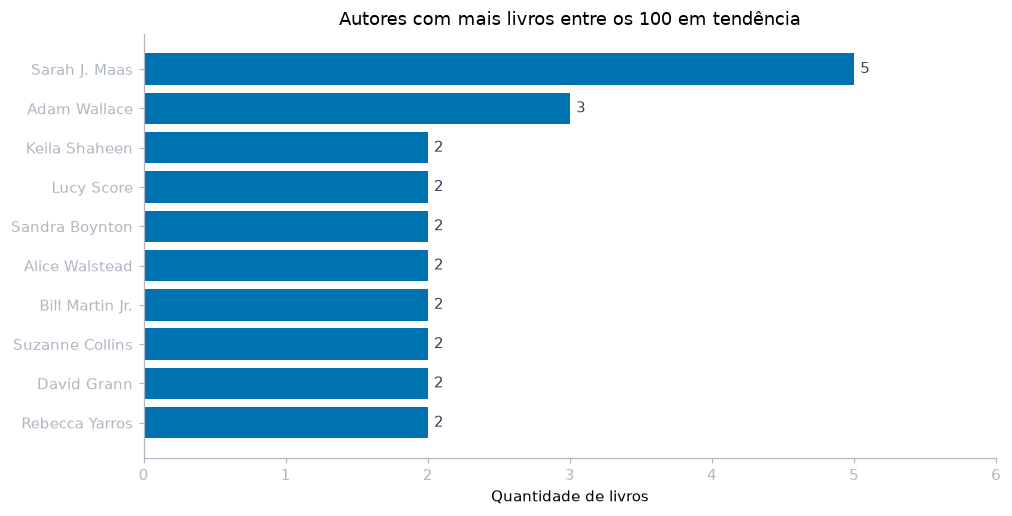

In [7]:
autores_grafico = resumo_autores.head(10).sort_values('livros')
fig, ax = plt.subplots(figsize=(10, 5))
barras = ax.barh(autores_grafico.index, autores_grafico['livros'], color=COR_PRIMARIA)
ax.bar_label(barras, labels=autores_grafico['livros'].astype(str), padding=4, color=COR_TEXTO)
ax.set(title='Autores com mais livros entre os 100 em tendência', xlabel='Quantidade de livros', xlim=(0, 6))
plt.show()

**Resultado:** Sarah J. Maas é a autora com maior presença, com cinco livros. Adam Wallace aparece três vezes. Os demais autores com recorrência têm dois títulos, portanto este ranking de presença não deve ser confundido com uma medida de vendas ou popularidade fora desta seleção de 100 livros.

## De quais anos vêm os livros em tendência?

Contamos os títulos por ano de publicação para distinguir lançamentos recentes de obras de catálogo.

In [8]:
resumo_ano = (
    livros.groupby('year of publication')
    .agg(livros=('book title', 'size'), preco_medio=('book price', 'mean'),
         nota_media=('rating', 'mean'), melhor_rank=('Rank', 'min'))
    .sort_index()
)
resumo_ano.tail(12)

,livros,preco_medio,nota_media,melhor_rank
year of publication,,,,
2013,1,9.43,4.80,26
2014,4,19.52,4.75,10
2015,5,10.27,4.64,23
2016,5,9.75,4.83,60
2017,5,8.27,4.68,9
2018,8,9.37,4.75,5
2019,3,7.90,4.73,42
2020,5,9.93,4.68,11
2021,6,21.06,4.67,28


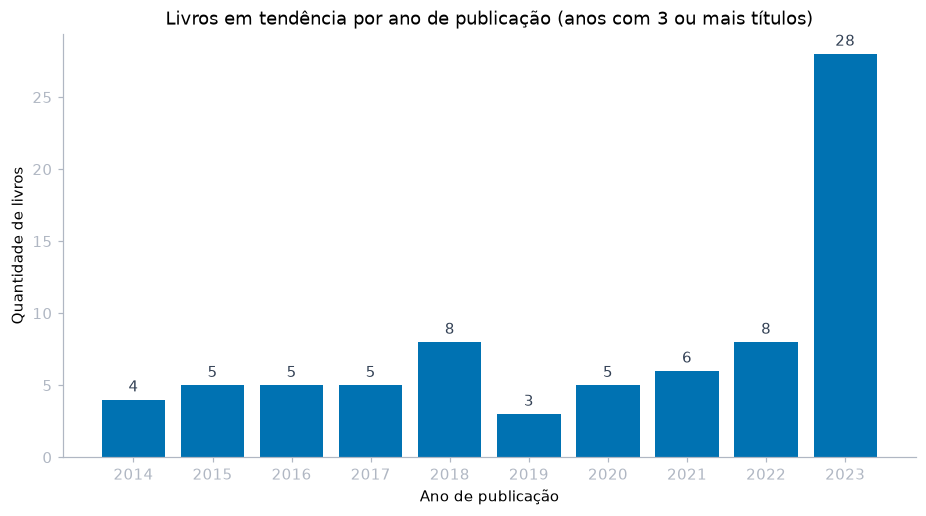

In [9]:
anos_grafico = resumo_ano.query('livros >= 3')
fig, ax = plt.subplots(figsize=(10, 5))
barras = ax.bar(anos_grafico.index.astype(str), anos_grafico['livros'], color=COR_PRIMARIA)
ax.bar_label(barras, labels=anos_grafico['livros'].astype(str), padding=3, color=COR_TEXTO)
ax.set(title='Livros em tendência por ano de publicação (anos com 3 ou mais títulos)', xlabel='Ano de publicação', ylabel='Quantidade de livros')
plt.show()

**Resultado:** lançamentos de 2023 concentram 28 livros, o maior volume da base. Entre 2014 e 2024 estão 78 dos 100 títulos; a presença de obras mais antigas mostra que a tendência também inclui catálogo, mas a seleção é predominantemente recente.

## Quais gêneros predominam no ranking?

Como os rótulos originais combinam múltiplas tags, usamos apenas o primeiro termo como genero_principal, uma aproximação explícita para comparar grupos.

In [10]:
livros['genero_principal'] = livros['genre'].str.split(',').str[0].str.strip()
livros[['genre', 'genero_principal']].head(5)

,genre,genero_principal
0,Fantasy Romance,Fantasy Romance
1,Memoir,Memoir
2,Autobiography,Autobiography
3,Memoir,Memoir
4,"Childrens, Fiction",Childrens


In [11]:
resumo_genero = (
    livros.groupby('genero_principal')
    .agg(livros=('book title', 'size'), preco_min=('book price', 'min'),
         preco_max=('book price', 'max'), preco_medio=('book price', 'mean'), nota_media=('rating', 'mean'))
    .sort_values(['livros', 'preco_medio'], ascending=[False, False])
)
resumo_genero.head(12)

,livros,preco_min,preco_max,preco_medio,nota_media
genero_principal,,,,,
Childrens,16,2.79,45.22,10.13,4.81
Picture Books,13,4.19,12.69,7.73,4.78
Nonfiction,12,5.90,27.43,14.45,4.61
Fantasy,9,8.89,48.77,20.17,4.78
Fiction,8,4.32,20.98,15.35,4.69
Self Help,3,17.28,20.11,18.62,4.65
Memoir,3,6.26,23.99,17.06,4.53
Thriller,3,9.44,19.89,13.44,4.43
Picture Book,3,3.78,7.74,5.49,4.83


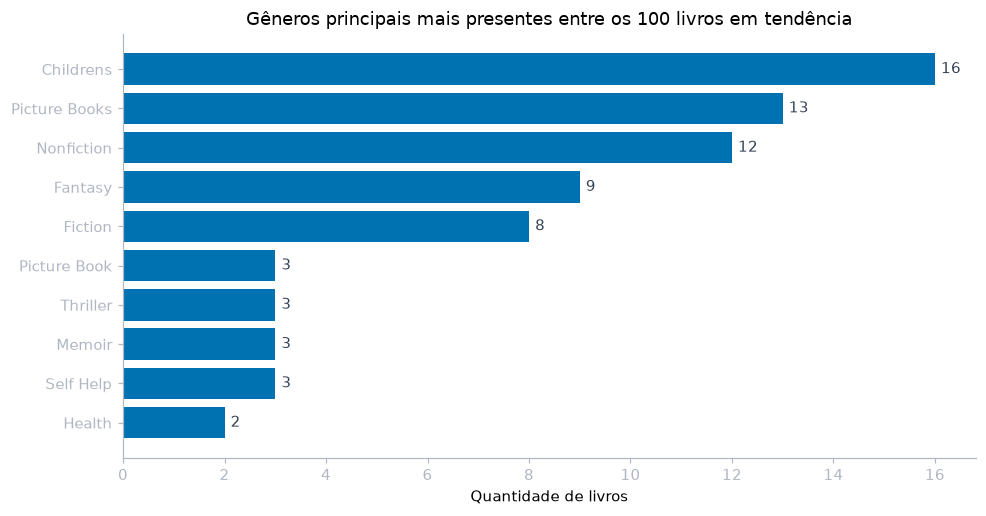

In [12]:
generos_grafico = resumo_genero.head(10).sort_values('livros')
fig, ax = plt.subplots(figsize=(10, 5))
barras = ax.barh(generos_grafico.index, generos_grafico['livros'], color=COR_PRIMARIA)
ax.bar_label(barras, labels=generos_grafico['livros'].astype(str), padding=4, color=COR_TEXTO)
ax.set(title='Gêneros principais mais presentes entre os 100 livros em tendência', xlabel='Quantidade de livros')
plt.show()

**Resultado:** Infantil (Childrens) lidera com 16 títulos, seguido por Picture Books com 13 e Nonfiction com 12. Como a classificação é uma simplificação da primeira tag e 84 livros pertencem a grupos com pelo menos dois casos, ela serve para descrever a composição — não para uma taxonomia editorial definitiva.

## Quais títulos compõem as 30 primeiras posições do ranking?

A tabela permite revisar diretamente os livros em maior evidência, com preço, avaliação e ano ao lado da posição.

In [13]:
top_30 = livros.loc[livros['Rank'].le(30), ['Rank', 'book title', 'author', 'rating', 'book price', 'year of publication', 'genero_principal']]
top_30.sort_values('Rank').style.format({'rating': '{:.1f}', 'book price': 'US dollars {:.2f}'})

,Rank,book title,author,rating,book price,year of publication,genero_principal
0,1,"Iron Flame (The Empyrean, 2)",Rebecca Yarros,4.1,US dollars 18.42,2023,Fantasy Romance
1,2,The Woman in Me,Britney Spears,4.5,US dollars 20.93,2023,Memoir
2,3,My Name Is Barbra,Barbra Streisand,4.5,US dollars 31.50,2023,Autobiography
3,4,"Friends, Lovers, and the Big Terrible Thing: A Memoir",Matthew Perry,4.4,US dollars 23.99,2023,Memoir
4,5,How to Catch a Turkey,Adam Wallace,4.8,US dollars 5.65,2018,Childrens
5,6,"Fourth Wing (The Empyrean, 1)",Rebecca Yarros,4.8,US dollars 16.99,2023,Fantasy
6,7,Unwoke: How to Defeat Cultural Marxism in America,Unknown,4.3,US dollars 27.43,2023,Nonfiction
7,8,No Brainer (Diary of a Wimpy Kid Book 18),Jeff Kinney,4.8,US dollars 8.55,2023,Humor
8,9,Killers of the Flower Moon: The Osage Murders and the Birth of the FBI,David Grann,4.4,US dollars 9.86,2017,Nonfiction
9,10,All the Light We Cannot See: A Novel,Anthony Doerr,4.5,US dollars 11.98,2014,Historical Fiction


**Resultado:** as 30 primeiras posições misturam lançamentos de 2023 com títulos de catálogo. Posição no ranking é uma ordenação da fonte e não deve ser interpretada como consequência do preço ou da nota, pois a base não informa vendas, data de coleta nem método de cálculo do ranking.

## Quais livros têm as maiores avaliações registradas?

Ordenamos as avaliações e mantemos a posição do ranking para separar nota de destaque no catálogo da colocação na tendência.

In [14]:
maiores_notas = (
    livros.dropna(subset=['rating'])
    .sort_values(['rating', 'Rank'], ascending=[False, True])
    .loc[:, ['Rank', 'book title', 'author', 'rating', 'book price']]
    .head(15)
)
maiores_notas.style.format({'rating': '{:.1f}', 'book price': 'US dollars {:.2f}'})

,Rank,book title,author,rating,book price
51,52,Resurrection Walk (Lincoln Lawyer),Michael Connelly,5.0,US dollars 20.98
18,19,Taylor Swift: A Little Golden Book Biography,Wendy Loggia,4.9,US dollars 4.78
26,27,"Goodnight, Goodnight Construction Site (Board Book for Toddlers, Children's Board Book)",Sherri Duskey Rinker,4.9,US dollars 3.78
29,30,"Brown Bear, Brown Bear, What Do You See?",Bill Martin Jr.,4.9,US dollars 4.94
30,31,Balloons over Broadway: The True Story of the Puppeteer of Macy's Parade (Bank Street College of Education Flora Stieglitz St,Bill Martin Jr.,4.9,US dollars 12.19
34,35,The Very Hungry Caterpillar,David Brooks,4.9,US dollars 5.90
36,37,Pookie's Thanksgiving (Little Pookie),Alice Walstead,4.9,US dollars 6.99
39,40,I Love You to the Moon and Back,Taylor Jenkins Reid,4.9,US dollars 4.76
43,44,Goodnight Moon,Margaret Wise Brown,4.9,US dollars 5.36
48,49,The Wonderful Things You Will Be,Emily Winfield Martin,4.9,US dollars 9.40


**Resultado:** apenas um título tem nota 5,0 e ele ocupa a posição 52. Vários livros infantis aparecem entre as notas 4,9, mas essas avaliações não explicam, por si só, a posição no ranking: o próprio primeiro colocado tem nota 4,1.

## Onde estão os maiores e menores preços por ano, gênero e autor?

Cada resumo mostra quantidade de livros e extremos de preço para evitar comparar uma média de grupo grande com a de um único título.

In [15]:
precos_por_ano = (
    livros.groupby('year of publication')
    .agg(livros=('book title', 'size'), menor_preco=('book price', 'min'), maior_preco=('book price', 'max'))
    .sort_values('maior_preco', ascending=False)
)
precos_por_ano.head(10).style.format({'menor_preco': 'US dollars {:.2f}', 'maior_preco': 'US dollars {:.2f}'})

,livros,menor_preco,maior_preco
year of publication,,,
2021,6,US dollars 10.39,US dollars 48.77
2014,4,US dollars 9.68,US dollars 45.22
2023,28,US dollars 4.78,US dollars 31.50
1999,1,US dollars 25.97,US dollars 25.97
2022,8,US dollars 6.93,US dollars 19.89
2016,5,US dollars 4.73,US dollars 17.99
2018,8,US dollars 2.79,US dollars 16.74
2024,1,US dollars 15.99,US dollars 15.99
2020,5,US dollars 5.37,US dollars 15.79


In [16]:
precos_por_genero = (
    resumo_genero.query('livros >= 2')
    .loc[:, ['livros', 'preco_min', 'preco_max', 'preco_medio']]
    .sort_values('preco_max', ascending=False)
)
precos_por_genero.head(12).style.format({'preco_min': 'US dollars {:.2f}', 'preco_max': 'US dollars {:.2f}', 'preco_medio': 'US dollars {:.2f}'})

,livros,preco_min,preco_max,preco_medio
genero_principal,,,,
Fantasy,9,US dollars 8.89,US dollars 48.77,US dollars 20.17
Childrens,16,US dollars 2.79,US dollars 45.22,US dollars 10.13
Nonfiction,12,US dollars 5.90,US dollars 27.43,US dollars 14.45
Memoir,3,US dollars 6.26,US dollars 23.99,US dollars 17.06
Fiction,8,US dollars 4.32,US dollars 20.98,US dollars 15.35
Dark,2,US dollars 13.36,US dollars 20.98,US dollars 17.17
Health,2,US dollars 16.99,US dollars 20.63,US dollars 18.81
Self Help,3,US dollars 17.28,US dollars 20.11,US dollars 18.62
Thriller,3,US dollars 9.44,US dollars 19.89,US dollars 13.44


In [17]:
precos_por_autor = (
    resumo_autores.loc[:, ['livros', 'preco_medio']]
    .join(livros.groupby('author')['book price'].agg(menor_preco='min', maior_preco='max'))
    .sort_values('maior_preco', ascending=False)
)
precos_por_autor.head(12).style.format({'menor_preco': 'US dollars {:.2f}', 'maior_preco': 'US dollars {:.2f}', 'preco_medio': 'US dollars {:.2f}'})

,livros,preco_medio,menor_preco,maior_preco
author,,,,
Sarah J. Maas,5,US dollars 20.10,US dollars 8.89,US dollars 48.77
J.K. Rowling,2,US dollars 35.59,US dollars 25.97,US dollars 45.22
Alice Walstead,2,US dollars 13.44,US dollars 6.99,US dollars 19.89
Keila Shaheen,2,US dollars 17.87,US dollars 17.28,US dollars 18.46
Rebecca Yarros,2,US dollars 17.70,US dollars 16.99,US dollars 18.42
Suzanne Collins,2,US dollars 13.39,US dollars 10.99,US dollars 15.79
David Grann,2,US dollars 12.58,US dollars 9.86,US dollars 15.30
Sandra Boynton,2,US dollars 8.19,US dollars 3.69,US dollars 12.68
Bill Martin Jr.,2,US dollars 8.56,US dollars 4.94,US dollars 12.19


**Resultado:** os maiores preços observados precisam ser lidos junto do número de títulos por grupo. Por exemplo, Fantasy atinge US dollars 48,77, e J.K. Rowling chega a US dollars 45,22, ambos em conjuntos pequenos. Os extremos por ano também podem refletir um único livro; eles descrevem a amostra, não um preço típico de todo o mercado.

## Tabela de consulta dos livros

Use os filtros para pesquisar título ou autor e limitar a visualização por gênero principal. A tabela mostra no máximo 20 registros por vez.

In [18]:
from ipywidgets import interact, widgets
from IPython.display import display

def explorar_livros(genero='Todos', busca=''):
    consulta = livros if genero == 'Todos' else livros[livros['genero_principal'] == genero]
    termo = busca.strip().lower()
    if termo:
        consulta = consulta[consulta['book title'].str.lower().str.contains(termo) | consulta['author'].str.lower().str.contains(termo)]
    display(consulta.sort_values('Rank')[['Rank', 'book title', 'author', 'rating', 'book price', 'year of publication', 'genero_principal']].head(20))

interact(explorar_livros, genero=widgets.Dropdown(options=['Todos'] + sorted(livros['genero_principal'].unique())), busca=widgets.Text());

interactive(children=(Dropdown(description='genero', options=('Todos', 'Adventure', 'Autobiography', 'Biograph…

## Síntese para acompanhamento do catálogo

**Achados**

- A seleção tem 100 posições únicas. Há forte concentração de publicações recentes: 28 títulos são de 2023 e 78 foram publicados entre 2014 e 2024.
- Sarah J. Maas aparece cinco vezes, a maior recorrência por autor. A contagem mede presença nesta lista, não vendas.
- Infantil, Picture Books e Nonfiction são os principais grupos quando se usa a primeira tag de gênero como aproximação.
- O top 30 combina lançamentos e catálogo; 13 posições são de livros de 2023. A nota não acompanha necessariamente a posição: o primeiro colocado tem 4,1, enquanto o único 5,0 está na posição 52.
- Os preços variam de US dollars 2,78 a US dollars 48,77. Os maiores valores pertencem a box sets, portanto não representam necessariamente preços usuais de livros avulsos.

**Limitações**

- A base não traz data de coleta, vendas, número de avaliações, país ou regra de cálculo do ranking. Não é possível explicar por que um título ocupa determinada posição.
- Três livros não têm avaliação e os gêneros originais misturam várias tags. O campo genero_principal foi criado somente para facilitar a comparação.
- A amostra representa estes 100 registros e não o mercado editorial como um todo.

**Próxima decisão sugerida**

Para monitorar tendências de forma contínua, registrar coletas recorrentes com data, vendas, unidades, avaliações e país permitiria medir entradas, saídas e evolução real do ranking.